     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 21.0 MB/s eta 0:00:00a 0:00:01
  Preparing metadata (setup.py) ... done
  DEPRECATION: Building 'japanize-matplotlib' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'japanize-matplotlib'. Discussion can be found at https://github.com/pypa/pip/issues/6334
  Created wheel for japanize-matplotlib: filename=japanize_matplotlib-1.1.3-py3-none-any.whl size=4120257 sha256=bd38dc032454d30643ba43e5060b12a632aab0f83b14bc6b915f3bb9ffcd2af3
  Stored in directory: /Users/tatsuyamahiroshitaira/Library/Caches/pip/wheels/56/8b/41/7c8a47025c6eef46f0b7488f2510fff13e48f1e7d5bf26e21b
Successfully built japanize-matplotlib


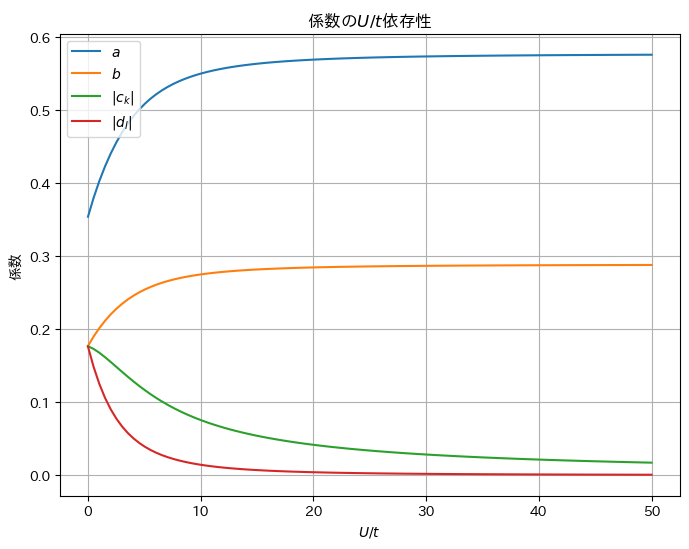

In [1]:
from __future__ import print_function

!pip install japanize-matplotlib

import matplotlib.pyplot as plt
import japanize_matplotlib

import numpy as np
# from hubbard_1site import make_local_ops, make_matrix, hermite_conjugate

np.set_printoptions(threshold=np.inf)

def make_local_ops():
    ops = {}

    # c^+
    cdag = np.zeros((2,2))
    cdag[1, 0] = 1
    ops['c^+'] = cdag

    # c
    c = cdag.transpose()
    ops['c'] = c

    # I
    ops['I'] = np.identity(2)

    # F (for fermionic anticommutation)
    ops['F'] = np.diag((1.0, -1.0))

    return ops


def make_matrix(*ops): #P189 *は可変長引数
    r = 1.0
    for op in ops[::-1]:
        r = np.kron(op, r)
    return r


def hermite_conjugate(mat):
    return mat.conj().T

def projection(h, n): #全粒子数状態を含むハミルトニアン h を与えて、粒子数 n の状態のブロックのみを取り出す関数
    from itertools import product #直積集合を作るため
    # occup = [sum(state) for state in product([0, 1], repeat=4)]
    # index = [i for i, occ in enumerate(occup) if occ == n]
    index = [i for i, state in enumerate(product([0, 1], repeat=8)) if sum(state)==n] #状態は16通り #enumerateで番号付
    return h[index, :][:, index]
              #行      　　 #列

def solve_hubbard_4site(t_L, t_S, U, mu=0, n=None):

    local_ops = make_local_ops()
    cdag = local_ops['c^+']
    I = local_ops['I']
    F = local_ops['F']

    # creation operators
    Cdag = {}
    Cdag['1u'] = make_matrix(I, I, I, I, I, I, I, cdag)
    Cdag['1d'] = make_matrix(I, I, I, I, I, I, cdag, F)
    Cdag['2u'] = make_matrix(I, I, I, I, I, cdag, F, F)
    Cdag['2d'] = make_matrix(I, I, I, I, cdag, F, F, F)
    Cdag['3u'] = make_matrix(I, I, I, cdag, F, F, F, F)
    Cdag['3d'] = make_matrix(I, I, cdag, F, F, F, F, F)
    Cdag['4u'] = make_matrix(I, cdag, F, F, F, F, F, F)
    Cdag['4d'] = make_matrix(cdag, F, F, F, F, F, F, F)

    C = {}  # annihilation operators
    N = {}  # number operators
    for key, cdag in Cdag.items():
        C[key] = hermite_conjugate(cdag)
        N[key] = cdag @ C[key]

    hamil = 0
    # t_L
    for key1, key2 in [('1u', '2u'), ('1d', '2d'), ('2u', '1u'), ('2d', '1d'), ('3u', '4u'), ('3d', '4d'), ('4u', '3u'), ('4d', '3d'), ('4u', '1u'), ('4d', '1d'), ('1u', '4u'), ('1d', '4d')]:
        hamil += -t_L * Cdag[key1] @ C[key2]

    # t_S
    for key1, key2 in [('2u', '3u'), ('2d', '3d'), ('3u', '2u'), ('3d', '2d')]:
        hamil += -t_S * Cdag[key1] @ C[key2]
    # U
    for key1, key2 in [('1u', '1d'), ('2u', '2d'), ('3u', '3d'), ('4u', '4d')]:
        hamil += U * N[key1] @ N[key2]
    # mu
    for n_op in N.values():
        hamil += -mu * n_op
    # print("H =\n", hamil-hamil.T)

    if n is not None:
        # projection to n-particle state
        hamil = projection(hamil, n)

    eigval, eigvec = np.linalg.eigh(hamil)

    N_i= {}
    N_j= {}

#    print(N_i)
    for key in ['1u', '1d', '2u', '2d', '3u', '3d', '4u', '4d']:
        N_i[key] = eigvec[:, 0].T @ N[key] @ eigvec[:, 0]
        N_j[key] = eigvec[:, 1].T @ N[key] @ eigvec[:, 1]

    N_sum=0
    for key in ['1u', '1d', '2u', '2d', '3u', '3d', '4u', '4d']:
        N_sum += N_i[key]

    return eigval, eigvec, N_i, round(N_sum, 1), eigvec[:, 0]


import matplotlib.pyplot as plt

import matplotlib.pyplot as plt

import numpy as np
import matplotlib.pyplot as plt

import numpy as np
import matplotlib.pyplot as plt

def main():
    t_L = 1.0
    t_S = 1.0
    U_values = np.linspace(0.01, 50, 100)  # U を 0.01 から 10 まで 100 分割

    eigvec_15_list = []
    eigvec_27_list = []
    eigvec_90_list = []
    eigvec_102_list = []

    for U in U_values:
        mu = U / 2
        _, _, _, _, eigvec_0 = solve_hubbard_4site(t_L, t_S, U, mu)

        eigvec_15_list.append(abs(eigvec_0[15]))
        eigvec_27_list.append(abs(eigvec_0[27]))
        eigvec_90_list.append(abs(eigvec_0[90]))
        eigvec_102_list.append(abs(eigvec_0[102]))

    # グラフ描画
    plt.figure(figsize=(8, 6))
    plt.plot(U_values, eigvec_102_list, label=r"$a$")
    plt.plot(U_values, eigvec_90_list, label=r"$b$")
    plt.plot(U_values, eigvec_27_list, label=r"$|c_k|$")
    plt.plot(U_values, eigvec_15_list, label=r"$|d_l|$")

    plt.xlabel("$\it{U/t}$")
    plt.ylabel("係数")
    plt.title("係数の$\it{U/t}$依存性")
    plt.legend()
    plt.grid(True)

    plt.show()

if __name__ == '__main__':
    main()




In [2]:
from __future__ import print_function #python3だと不要かも

import numpy as np
# from hubbard_1site import make_local_ops, make_matrix, hermite_conjugate

np.set_printoptions(threshold=np.inf)

def make_local_ops():
    ops = {}

    # c^+
    cdag = np.zeros((2,2))
    cdag[1, 0] = 1
    ops['c^+'] = cdag

    # c
    c = cdag.transpose()
    ops['c'] = c

    # I
    ops['I'] = np.identity(2)

    # F (for fermionic anticommutation)
    ops['F'] = np.diag((1.0, -1.0))

    return ops


def make_matrix(*ops): #P189 *は可変長引数
    r = 1.0
    for op in ops[::-1]:
        r = np.kron(op, r)
    return r


def hermite_conjugate(mat):
    return mat.conj().T

def projection(h, n): #全粒子数状態を含むハミルトニアン h を与えて、粒子数 n の状態のブロックのみを取り出す関数
    from itertools import product #直積集合を作るため
    # occup = [sum(state) for state in product([0, 1], repeat=4)]
    # index = [i for i, occ in enumerate(occup) if occ == n]
    index = [i for i, state in enumerate(product([0, 1], repeat=8)) if sum(state)==n] #状態は16通り #enumerateで番号付
    return h[index, :][:, index]
              #行      　　 #列

def solve_hubbard_4site(t_L, t_S, U, mu=0, n=None):

    local_ops = make_local_ops()
    cdag = local_ops['c^+']
    I = local_ops['I']
    F = local_ops['F']

    # creation operators
    Cdag = {}
    Cdag['1u'] = make_matrix(I, I, I, I, I, I, I, cdag)
    Cdag['1d'] = make_matrix(I, I, I, I, I, I, cdag, F)
    Cdag['2u'] = make_matrix(I, I, I, I, I, cdag, F, F)
    Cdag['2d'] = make_matrix(I, I, I, I, cdag, F, F, F)
    Cdag['3u'] = make_matrix(I, I, I, cdag, F, F, F, F)
    Cdag['3d'] = make_matrix(I, I, cdag, F, F, F, F, F)
    Cdag['4u'] = make_matrix(I, cdag, F, F, F, F, F, F)
    Cdag['4d'] = make_matrix(cdag, F, F, F, F, F, F, F)

    C = {}  # annihilation operators
    N = {}  # number operators
    for key, cdag in Cdag.items():
        C[key] = hermite_conjugate(cdag)
        N[key] = cdag @ C[key]

    hamil = 0
    # t_L
    for key1, key2 in [('1u', '2u'), ('1d', '2d'), ('2u', '1u'), ('2d', '1d'), ('3u', '4u'), ('3d', '4d'), ('4u', '3u'), ('4d', '3d'), ('4u', '1u'), ('4d', '1d'), ('1u', '4u'), ('1d', '4d')]:
        hamil += -t_L * Cdag[key1] @ C[key2]

    # t_S
    for key1, key2 in [('2u', '3u'), ('2d', '3d'), ('3u', '2u'), ('3d', '2d')]:
        hamil += -t_S * Cdag[key1] @ C[key2]
    # U
    for key1, key2 in [('1u', '1d'), ('2u', '2d'), ('3u', '3d'), ('4u', '4d')]:
        hamil += U * N[key1] @ N[key2]
    # mu
    for n_op in N.values():
        hamil += -mu * n_op
    # print("H =\n", hamil-hamil.T)

    if n is not None:
        # projection to n-particle state
        hamil = projection(hamil, n)

    eigval, eigvec = np.linalg.eigh(hamil)

    N_i= {}
    N_j= {}

#    print(N_i)
    for key in ['1u', '1d', '2u', '2d', '3u', '3d', '4u', '4d']:
        N_i[key] = eigvec[:, 0].T @ N[key] @ eigvec[:, 0]
        N_j[key] = eigvec[:, 1].T @ N[key] @ eigvec[:, 1]

    N_sum=0
    for key in ['1u', '1d', '2u', '2d', '3u', '3d', '4u', '4d']:
        N_sum += N_i[key]

    return eigval, eigvec, N_i, round(N_sum, 1), eigvec[:, 0]


def main():
    t_L = 1.0
    t_S = 1.0
    # for i in range (0,100,1):
    U = 0.2
    mu = U/2

    E, vec, N_i, N_sum ,eigvec_0= solve_hubbard_4site(t_L, t_S, U, mu)
    # E, vec = solve_hubbard_9site(t_L, t_S, U, mu, n=4)

    # print("\nE =\n", E)
    print(np.round(eigvec_0, 3))
    # print("U=",U,N_sum,N_i)

    # for i in range(vec.shape[1]):
    #     print(vec[:, i])


if __name__ == '__main__':
    main()

[ 0.     0.    -0.     0.     0.     0.    -0.    -0.     0.    -0.
  0.    -0.    -0.    -0.     0.    -0.165 -0.    -0.     0.    -0.
 -0.    -0.     0.     0.    -0.    -0.    -0.     0.176 -0.    -0.
 -0.    -0.    -0.    -0.     0.    -0.     0.    -0.     0.    -0.176
  0.    -0.    -0.    -0.    -0.    -0.     0.    -0.     0.     0.
  0.    -0.     0.     0.    -0.176  0.     0.     0.176 -0.    -0.
  0.165 -0.    -0.     0.     0.    -0.     0.    -0.    -0.    -0.
  0.     0.    -0.    -0.    -0.     0.    -0.    -0.     0.176 -0.
  0.    -0.     0.     0.    -0.     0.    -0.     0.     0.     0.
 -0.182  0.     0.     0.    -0.     0.    -0.    -0.    -0.    -0.176
 -0.    -0.     0.364 -0.    -0.    -0.182  0.    -0.    -0.176  0.
  0.     0.    -0.    -0.     0.176 -0.    -0.     0.     0.     0.
 -0.    -0.     0.     0.    -0.     0.     0.     0.    -0.    -0.
  0.    -0.     0.    -0.     0.     0.    -0.    -0.    -0.    -0.
 -0.    -0.176  0.     0.    -0.     0.   

In [1]:
import numpy as np

def solve_hf_4site(t_L, t_S, U, mu, max_iter=1000, tol=1e-8):
    N_sites = 4
    
    # 1. ホッピング行列 T の構築 (1体ハミルトニアンの運動エネルギー部分)
    # サイト番号は元のコードの 1, 2, 3, 4 をそれぞれ 0, 1, 2, 3 に対応させます
    T = np.zeros((N_sites, N_sites))
    
    # 元コードの接続関係を反映:
    # t_L: (0,1), (2,3), (3,0)  /  t_S: (1,2)
    edges_L = [(0, 1), (2, 3), (3, 0)]
    edges_S = [(1, 2)]
    
    for i, j in edges_L:
        T[i, j] = T[j, i] = -t_L
    for i, j in edges_S:
        T[i, j] = T[j, i] = -t_S
        
    # 2. 粒子数期待値の初期設定
    # 相互作用がある場合、対称性が破れた状態（例: 反強磁性）に落ちる可能性があるため、
    # 意図的に非対称な初期値を与えてループを回します。
    n_up = np.array([0.8, 0.2, 0.8, 0.2])
    n_dn = np.array([0.2, 0.8, 0.2, 0.8])
    
    # 自己無撞着（セルフコンシステント）ループ
    for iteration in range(max_iter):
        # 平均場ハミルトニアンの構築 (化学ポテンシャル mu を対角成分に含む)
        H_up = T + np.diag(U * n_dn) - np.eye(N_sites) * mu
        H_dn = T + np.diag(U * n_up) - np.eye(N_sites) * mu
        
        # 対角化 (1体ハミルトニアンなので 4x4 行列の対角化)
        eigval_up, eigvec_up = np.linalg.eigh(H_up)
        eigval_dn, eigvec_dn = np.linalg.eigh(H_dn)
        
        # 占有状態の判定: 固有値にすでに -mu が含まれているため、
        # エネルギーが負（フェルミ準位以下）の状態を占有するとみなします。
        occ_up = eigval_up < 0
        occ_dn = eigval_dn < 0
        
        # 新しい粒子数期待値の計算
        new_n_up = np.zeros(N_sites)
        new_n_dn = np.zeros(N_sites)
        
        for i in range(N_sites):
            # 占有状態の固有ベクトルから各サイトの確率振幅を足し合わせる
            new_n_up[i] = np.sum(occ_up * np.abs(eigvec_up[i, :])**2)
            new_n_dn[i] = np.sum(occ_dn * np.abs(eigvec_dn[i, :])**2)
            
        # 収束判定
        diff = np.max(np.abs(new_n_up - n_up)) + np.max(np.abs(new_n_dn - n_dn))
        if diff < tol:
            n_up, n_dn = new_n_up, new_n_dn
            break
            
        # ミキシング (解が振動して収束しなくなるのを防ぐために前回の値と混ぜて更新します)
        alpha = 0.5
        n_up = alpha * new_n_up + (1 - alpha) * n_up
        n_dn = alpha * new_n_dn + (1 - alpha) * n_dn
        
    # 3. 基底状態エネルギー (グランドポテンシャル) の計算
    # 1体のエネルギーの総和から、平均場で二重カウントされている相互作用エネルギーを引きます
    energy = np.sum(eigval_up[occ_up]) + np.sum(eigval_dn[occ_dn]) - U * np.sum(n_up * n_dn)
    
    return energy, n_up, n_dn, iteration

def main():
    t_L = 1.0
    t_S = 1.0
    U = 0.2
    mu = U / 2
    
    E_hf, n_up, n_dn, iters = solve_hf_4site(t_L, t_S, U, mu)
    
    print(f"Hartree-Fock Energy (Grand Potential): {E_hf:.6f}")
    print(f"Converged in {iters} iterations.")
    print("-" * 30)
    print("Site expectation values <n_i_up>:")
    print(np.round(n_up, 3))
    print("Site expectation values <n_i_dn>:")
    print(np.round(n_dn, 3))
    
    total_N = np.sum(n_up) + np.sum(n_dn)
    print("-" * 30)
    print(f"Total particle number: {total_N:.3f}")

if __name__ == '__main__':
    main()

Hartree-Fock Energy (Grand Potential): -4.251282
Converged in 24 iterations.
------------------------------
Site expectation values <n_i_up>:
[0.756 0.244 0.756 0.244]
Site expectation values <n_i_dn>:
[0.244 0.756 0.244 0.756]
------------------------------
Total particle number: 4.000


In [2]:
from __future__ import print_function

import numpy as np
from itertools import product

np.set_printoptions(threshold=np.inf)

def make_local_ops():
    ops = {}
    cdag = np.zeros((2,2))
    cdag[1, 0] = 1
    ops['c^+'] = cdag
    c = cdag.transpose()
    ops['c'] = c
    ops['I'] = np.identity(2)
    ops['F'] = np.diag((1.0, -1.0))
    return ops

def make_matrix(*ops):
    r = 1.0
    for op in ops[::-1]:
        r = np.kron(op, r)
    return r

def hermite_conjugate(mat):
    return mat.conj().T

def projection(h, n):
    index = [i for i, state in enumerate(product([0, 1], repeat=8)) if sum(state)==n]
    return h[index, :][:, index]

def solve_hubbard_4site(t_L, t_S, U, mu=0, n=None):

    local_ops = make_local_ops()
    cdag = local_ops['c^+']
    I = local_ops['I']
    F = local_ops['F']

    Cdag = {}
    Cdag['1u'] = make_matrix(I, I, I, I, I, I, I, cdag)
    Cdag['1d'] = make_matrix(I, I, I, I, I, I, cdag, F)
    Cdag['2u'] = make_matrix(I, I, I, I, I, cdag, F, F)
    Cdag['2d'] = make_matrix(I, I, I, I, cdag, F, F, F)
    Cdag['3u'] = make_matrix(I, I, I, cdag, F, F, F, F)
    Cdag['3d'] = make_matrix(I, I, cdag, F, F, F, F, F)
    Cdag['4u'] = make_matrix(I, cdag, F, F, F, F, F, F)
    Cdag['4d'] = make_matrix(cdag, F, F, F, F, F, F, F)

    C = {}  
    N = {}  
    for key, c_op in Cdag.items():
        C[key] = hermite_conjugate(c_op)
        N[key] = c_op @ C[key]

    hamil = 0
    # t_L
    for key1, key2 in [('1u', '2u'), ('1d', '2d'), ('2u', '1u'), ('2d', '1d'), ('3u', '4u'), ('3d', '4d'), ('4u', '3u'), ('4d', '3d'), ('4u', '1u'), ('4d', '1d'), ('1u', '4u'), ('1d', '4d')]:
        hamil += -t_L * Cdag[key1] @ C[key2]

    # t_S
    for key1, key2 in [('2u', '3u'), ('2d', '3d'), ('3u', '2u'), ('3d', '2d')]:
        hamil += -t_S * Cdag[key1] @ C[key2]
    # U
    for key1, key2 in [('1u', '1d'), ('2u', '2d'), ('3u', '3d'), ('4u', '4d')]:
        hamil += U * N[key1] @ N[key2]
    # mu
    for n_op in N.values():
        hamil += -mu * n_op

    if n is not None:
        hamil = projection(hamil, n)

    eigval, eigvec = np.linalg.eigh(hamil)
    eigvec_0 = eigvec[:, 0]

    N_i= {}
    for key in ['1u', '1d', '2u', '2d', '3u', '3d', '4u', '4d']:
        N_i[key] = eigvec_0.T @ N[key] @ eigvec_0

    N_sum=0
    for key in ['1u', '1d', '2u', '2d', '3u', '3d', '4u', '4d']:
        N_sum += N_i[key]

    # ===== 追加部分: 1粒子密度行列の計算 =====
    rho_up = np.zeros((4, 4))
    rho_dn = np.zeros((4, 4))
    
    for i in range(1, 5):
        for j in range(1, 5):
            # <Psi0| c^+_i c_j |Psi0> (スピンアップ)
            op_up = Cdag[f'{i}u'] @ C[f'{j}u']
            rho_up[i-1, j-1] = np.real(eigvec_0.T @ op_up @ eigvec_0)
            
            # <Psi0| c^+_i c_j |Psi0> (スピンダウン)
            op_dn = Cdag[f'{i}d'] @ C[f'{j}d']
            rho_dn[i-1, j-1] = np.real(eigvec_0.T @ op_dn @ eigvec_0)
    # =========================================

    return eigval, eigvec_0, N_i, round(N_sum, 1), rho_up, rho_dn

def main():
    t_L = 1.0
    t_S = 1.0
    U = 0.2
    mu = U/2

    E, eigvec_0, N_i, N_sum, rho_up, rho_dn = solve_hubbard_4site(t_L, t_S, U, mu)

    print(f"Ground State Energy: {E[0]:.6f}")
    print("-" * 40)
    print("1-body Density Matrix (Spin UP):")
    print(np.round(rho_up, 4))
    print("\n1-body Density Matrix (Spin DOWN):")
    print(np.round(rho_dn, 4))
    print("-" * 40)
    
    # 確認用: 対角成分がサイトごとの粒子数になっているか
    print("Diagonal elements of rho_up (Local density <n_i_up>):")
    print(np.round(np.diag(rho_up), 4))

if __name__ == '__main__':
    main()

Ground State Energy: -4.253970
----------------------------------------
1-body Density Matrix (Spin UP):
[[ 0.5     0.2498 -0.      0.2498]
 [ 0.2498  0.5     0.2498  0.    ]
 [-0.      0.2498  0.5     0.2498]
 [ 0.2498  0.      0.2498  0.5   ]]

1-body Density Matrix (Spin DOWN):
[[ 0.5     0.2498  0.      0.2498]
 [ 0.2498  0.5     0.2498 -0.    ]
 [ 0.      0.2498  0.5     0.2498]
 [ 0.2498 -0.      0.2498  0.5   ]]
----------------------------------------
Diagonal elements of rho_up (Local density <n_i_up>):
[0.5 0.5 0.5 0.5]


In [4]:
from __future__ import print_function

import numpy as np
from itertools import product

np.set_printoptions(threshold=np.inf)

def make_local_ops():
    ops = {}
    cdag = np.zeros((2,2))
    cdag[1, 0] = 1
    ops['c^+'] = cdag
    c = cdag.transpose()
    ops['c'] = c
    ops['I'] = np.identity(2)
    ops['F'] = np.diag((1.0, -1.0))
    return ops

def make_matrix(*ops):
    r = 1.0
    for op in ops[::-1]:
        r = np.kron(op, r)
    return r

def hermite_conjugate(mat):
    return mat.conj().T

def projection(h, n):
    index = [i for i, state in enumerate(product([0, 1], repeat=8)) if sum(state)==n]
    return h[index, :][:, index]

def solve_hubbard_4site(t_L, t_S, U, mu=0, n=None):

    local_ops = make_local_ops()
    cdag = local_ops['c^+']
    I = local_ops['I']
    F = local_ops['F']

    Cdag = {}
    Cdag['1u'] = make_matrix(I, I, I, I, I, I, I, cdag)
    Cdag['1d'] = make_matrix(I, I, I, I, I, I, cdag, F)
    Cdag['2u'] = make_matrix(I, I, I, I, I, cdag, F, F)
    Cdag['2d'] = make_matrix(I, I, I, I, cdag, F, F, F)
    Cdag['3u'] = make_matrix(I, I, I, cdag, F, F, F, F)
    Cdag['3d'] = make_matrix(I, I, cdag, F, F, F, F, F)
    Cdag['4u'] = make_matrix(I, cdag, F, F, F, F, F, F)
    Cdag['4d'] = make_matrix(cdag, F, F, F, F, F, F, F)

    C = {}  
    N = {}  
    for key, c_op in Cdag.items():
        C[key] = hermite_conjugate(c_op)
        N[key] = c_op @ C[key]

    hamil = 0
    # t_L
    for key1, key2 in [('1u', '2u'), ('1d', '2d'), ('2u', '1u'), ('2d', '1d'), ('3u', '4u'), ('3d', '4d'), ('4u', '3u'), ('4d', '3d'), ('4u', '1u'), ('4d', '1d'), ('1u', '4u'), ('1d', '4d')]:
        hamil += -t_L * Cdag[key1] @ C[key2]

    # t_S
    for key1, key2 in [('2u', '3u'), ('2d', '3d'), ('3u', '2u'), ('3d', '2d')]:
        hamil += -t_S * Cdag[key1] @ C[key2]
    # U
    for key1, key2 in [('1u', '1d'), ('2u', '2d'), ('3u', '3d'), ('4u', '4d')]:
        hamil += U * N[key1] @ N[key2]
    # mu
    for n_op in N.values():
        hamil += -mu * n_op

    if n is not None:
        hamil = projection(hamil, n)

    eigval, eigvec = np.linalg.eigh(hamil)
    eigvec_0 = eigvec[:, 0]

    N_i= {}
    for key in ['1u', '1d', '2u', '2d', '3u', '3d', '4u', '4d']:
        N_i[key] = eigvec_0.T @ N[key] @ eigvec_0

    N_sum=0
    for key in ['1u', '1d', '2u', '2d', '3u', '3d', '4u', '4d']:
        N_sum += N_i[key]

    # ===== 1粒子密度行列の計算 =====
    rho_up = np.zeros((4, 4))
    rho_dn = np.zeros((4, 4))
    
    for i in range(1, 5):
        for j in range(1, 5):
            op_up = Cdag[f'{i}u'] @ C[f'{j}u']
            rho_up[i-1, j-1] = np.real(eigvec_0.T @ op_up @ eigvec_0)
            
            op_dn = Cdag[f'{i}d'] @ C[f'{j}d']
            rho_dn[i-1, j-1] = np.real(eigvec_0.T @ op_dn @ eigvec_0)

    return eigval, eigvec_0, N_i, round(N_sum, 1), rho_up, rho_dn

def main():
    t_L = 1.0
    t_S = 1.0
    U = 0.2
    mu = U/2

    E, eigvec_0, N_i, N_sum, rho_up, rho_dn = solve_hubbard_4site(t_L, t_S, U, mu)

    print(f"Ground State Energy: {E[0]:.6f}")
    print("-" * 40)
    print("1-body Density Matrix (Spin UP):")
    print(np.round(rho_up, 4))
    print("\n1-body Density Matrix (Spin DOWN):")
    print(np.round(rho_dn, 4))
    print("-" * 40)
    
    # 追加部分: 基底状態の状態ベクトルを出力
    print("\nGround State Vector (eigvec_0):")
    print(np.round(eigvec_0, 3))

if __name__ == '__main__':
    main()

Ground State Energy: -4.253970
----------------------------------------
1-body Density Matrix (Spin UP):
[[ 0.5     0.2498 -0.      0.2498]
 [ 0.2498  0.5     0.2498  0.    ]
 [-0.      0.2498  0.5     0.2498]
 [ 0.2498  0.      0.2498  0.5   ]]

1-body Density Matrix (Spin DOWN):
[[ 0.5     0.2498  0.      0.2498]
 [ 0.2498  0.5     0.2498 -0.    ]
 [ 0.      0.2498  0.5     0.2498]
 [ 0.2498 -0.      0.2498  0.5   ]]
----------------------------------------

Ground State Vector (eigvec_0):
[ 0.     0.    -0.     0.     0.     0.    -0.    -0.     0.    -0.
  0.    -0.    -0.    -0.     0.    -0.165 -0.    -0.     0.    -0.
 -0.    -0.     0.     0.    -0.    -0.    -0.     0.176 -0.    -0.
 -0.    -0.    -0.    -0.     0.    -0.     0.    -0.     0.    -0.176
  0.    -0.    -0.    -0.    -0.    -0.     0.    -0.     0.     0.
  0.    -0.     0.     0.    -0.176  0.     0.     0.176 -0.    -0.
  0.165 -0.    -0.     0.     0.    -0.     0.    -0.    -0.    -0.
  0.     0.    -0.    -0

In [6]:
from __future__ import print_function

import numpy as np
from itertools import product

np.set_printoptions(threshold=np.inf)

def make_local_ops():
    ops = {}
    cdag = np.zeros((2,2))
    cdag[1, 0] = 1
    ops['c^+'] = cdag
    c = cdag.transpose()
    ops['c'] = c
    ops['I'] = np.identity(2)
    ops['F'] = np.diag((1.0, -1.0))
    return ops

def make_matrix(*ops):
    r = 1.0
    for op in ops[::-1]:
        r = np.kron(op, r)
    return r

def hermite_conjugate(mat):
    return mat.conj().T

def solve_hf_state_vector(t_L, t_S, U, mu, max_iter=1000, tol=1e-8):
    N_sites = 4
    
    # 1. ホッピング行列 T の構築
    T = np.zeros((N_sites, N_sites))
    edges_L = [(0, 1), (2, 3), (3, 0)]
    edges_S = [(1, 2)]
    
    for i, j in edges_L:
        T[i, j] = T[j, i] = -t_L
    for i, j in edges_S:
        T[i, j] = T[j, i] = -t_S
        
    # 反強磁性的な初期状態
    n_up = np.array([0.8, 0.2, 0.8, 0.2])
    n_dn = np.array([0.2, 0.8, 0.2, 0.8])
    
    # 自己無撞着ループ
    for iteration in range(max_iter):
        H_up = T + np.diag(U * n_dn) - np.eye(N_sites) * mu
        H_dn = T + np.diag(U * n_up) - np.eye(N_sites) * mu
        
        eigval_up, eigvec_up = np.linalg.eigh(H_up)
        eigval_dn, eigvec_dn = np.linalg.eigh(H_dn)
        
        # ハーフフィリング（各スピン2個ずつ占有）
        new_n_up = eigvec_up[:, 0]**2 + eigvec_up[:, 1]**2
        new_n_dn = eigvec_dn[:, 0]**2 + eigvec_dn[:, 1]**2
            
        diff = np.max(np.abs(new_n_up - n_up)) + np.max(np.abs(new_n_dn - n_dn))
        if diff < tol:
            break
            
        alpha = 0.5
        n_up = alpha * new_n_up + (1 - alpha) * n_up
        n_dn = alpha * new_n_dn + (1 - alpha) * n_dn

    # 2. フルFock空間(256次元)における状態ベクトルの構築
    local_ops = make_local_ops()
    cdag = local_ops['c^+']
    I = local_ops['I']
    F = local_ops['F']

    Cdag = {}
    Cdag['1u'] = make_matrix(I, I, I, I, I, I, I, cdag)
    Cdag['1d'] = make_matrix(I, I, I, I, I, I, cdag, F)
    Cdag['2u'] = make_matrix(I, I, I, I, I, cdag, F, F)
    Cdag['2d'] = make_matrix(I, I, I, I, cdag, F, F, F)
    Cdag['3u'] = make_matrix(I, I, I, cdag, F, F, F, F)
    Cdag['3d'] = make_matrix(I, I, cdag, F, F, F, F, F)
    Cdag['4u'] = make_matrix(I, cdag, F, F, F, F, F, F)
    Cdag['4d'] = make_matrix(cdag, F, F, F, F, F, F, F)
    
    # 占有される HF 軌道の生成演算子を作成（1粒子固有ベクトルでの線形結合）
    # k=0, 1 (下から2つの軌道) が占有される
    Ddag_up_0 = sum(eigvec_up[i, 0] * Cdag[f'{i+1}u'] for i in range(4))
    Ddag_up_1 = sum(eigvec_up[i, 1] * Cdag[f'{i+1}u'] for i in range(4))
    Ddag_dn_0 = sum(eigvec_dn[i, 0] * Cdag[f'{i+1}d'] for i in range(4))
    Ddag_dn_1 = sum(eigvec_dn[i, 1] * Cdag[f'{i+1}d'] for i in range(4))
    
    # 真空状態ベクトル (2^8 = 256 次元)
    vac = np.zeros(256)
    vac[0] = 1.0  # 状態 [0,0,0,0,0,0,0,0] がインデックス0
    
    # 真空状態に HF の生成演算子を作用させてスレイター行列式を作る
    hf_state = Ddag_up_0 @ Ddag_up_1 @ Ddag_dn_0 @ Ddag_dn_1 @ vac
    
    # 規格化
    hf_state = hf_state / np.linalg.norm(hf_state)
    
    return hf_state

def main():
    t_L = 1.0
    t_S = 1.0
    U = 0.2
    mu = U / 2

    # HF近似による状態ベクトルの取得
    hf_vec = solve_hf_state_vector(t_L, t_S, U, mu)

    print("Hartree-Fock Ground State Vector (256-dim):")
    print(np.round(hf_vec, 3))

if __name__ == '__main__':
    main()

Hartree-Fock Ground State Vector (256-dim):
[ 0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
  0.     0.     0.     0.     0.    -0.122  0.     0.     0.     0.
  0.     0.     0.     0.     0.     0.     0.     0.25   0.     0.
 -0.122  0.     0.     0.     0.     0.     0.     0.     0.    -0.
  0.     0.     0.     0.     0.    -0.122  0.     0.     0.     0.
  0.    -0.     0.     0.     0.     0.     0.     0.25   0.     0.
  0.122  0.     0.     0.     0.     0.     0.     0.     0.     0.
  0.     0.     0.     0.     0.     0.122  0.     0.     0.     0.
  0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
 -0.122  0.     0.     0.     0.     0.     0.     0.     0.     0.
  0.     0.     0.     0.     0.    -0.122  0.     0.     0.     0.
  0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
 -0.122  0.     0.     0.     0.     0.     0.     0.     0.     0.
  0.     0.     0.     0.     0.     0.122  0.     0.     0.     0.
  0.

In [8]:
from __future__ import print_function

import numpy as np
from itertools import product

np.set_printoptions(threshold=np.inf)

# ==========================================
# 共通の演算子構築用関数
# ==========================================
def make_local_ops():
    ops = {}
    cdag = np.zeros((2,2))
    cdag[1, 0] = 1
    ops['c^+'] = cdag
    ops['c'] = cdag.transpose()
    ops['I'] = np.identity(2)
    ops['F'] = np.diag((1.0, -1.0))
    return ops

def make_matrix(*ops):
    r = 1.0
    for op in ops[::-1]:
        r = np.kron(op, r)
    return r

def hermite_conjugate(mat):
    return mat.conj().T

def get_creation_ops():
    """256次元空間の生成演算子 Cdag の辞書を返す"""
    local_ops = make_local_ops()
    cdag = local_ops['c^+']
    I = local_ops['I']
    F = local_ops['F']

    Cdag = {}
    Cdag['1u'] = make_matrix(I, I, I, I, I, I, I, cdag)
    Cdag['1d'] = make_matrix(I, I, I, I, I, I, cdag, F)
    Cdag['2u'] = make_matrix(I, I, I, I, I, cdag, F, F)
    Cdag['2d'] = make_matrix(I, I, I, I, cdag, F, F, F)
    Cdag['3u'] = make_matrix(I, I, I, cdag, F, F, F, F)
    Cdag['3d'] = make_matrix(I, I, cdag, F, F, F, F, F)
    Cdag['4u'] = make_matrix(I, cdag, F, F, F, F, F, F)
    Cdag['4d'] = make_matrix(cdag, F, F, F, F, F, F, F)
    return Cdag

# ==========================================
# 1. 厳密対角化 (Exact Diagonalization)
# ==========================================
def solve_ed_state_vector(t_L, t_S, U, mu):
    Cdag = get_creation_ops()
    
    C = {}  
    N = {}  
    for key, c_op in Cdag.items():
        C[key] = hermite_conjugate(c_op)
        N[key] = c_op @ C[key]

    hamil = 0
    # t_L
    for key1, key2 in [('1u', '2u'), ('1d', '2d'), ('2u', '1u'), ('2d', '1d'), ('3u', '4u'), ('3d', '4d'), ('4u', '3u'), ('4d', '3d'), ('4u', '1u'), ('4d', '1d'), ('1u', '4u'), ('1d', '4d')]:
        hamil += -t_L * Cdag[key1] @ C[key2]
    # t_S
    for key1, key2 in [('2u', '3u'), ('2d', '3d'), ('3u', '2u'), ('3d', '2d')]:
        hamil += -t_S * Cdag[key1] @ C[key2]
    # U
    for key1, key2 in [('1u', '1d'), ('2u', '2d'), ('3u', '3d'), ('4u', '4d')]:
        hamil += U * N[key1] @ N[key2]
    # mu
    for n_op in N.values():
        hamil += -mu * n_op

    eigval, eigvec = np.linalg.eigh(hamil)
    return eigvec[:, 0]  # 基底状態ベクトル (256次元) を返す

# ==========================================
# 2. ハートリーフォック近似 (Hartree-Fock)
# ==========================================
def solve_hf_state_vector(t_L, t_S, U, mu, max_iter=1000, tol=1e-8):
    N_sites = 4
    
    # ホッピング行列 T
    T = np.zeros((N_sites, N_sites))
    edges_L = [(0, 1), (2, 3), (3, 0)]
    edges_S = [(1, 2)]
    
    for i, j in edges_L:
        T[i, j] = T[j, i] = -t_L
    for i, j in edges_S:
        T[i, j] = T[j, i] = -t_S
        
    # 反強磁性的な初期状態
    n_up = np.array([0.8, 0.2, 0.8, 0.2])
    n_dn = np.array([0.2, 0.8, 0.2, 0.8])
    
    # 自己無撞着ループ
    for iteration in range(max_iter):
        H_up = T + np.diag(U * n_dn) - np.eye(N_sites) * mu
        H_dn = T + np.diag(U * n_up) - np.eye(N_sites) * mu
        
        eigval_up, eigvec_up = np.linalg.eigh(H_up)
        eigval_dn, eigvec_dn = np.linalg.eigh(H_dn)
        
        # ハーフフィリング（各スピン下から2軌道を占有）
        new_n_up = eigvec_up[:, 0]**2 + eigvec_up[:, 1]**2
        new_n_dn = eigvec_dn[:, 0]**2 + eigvec_dn[:, 1]**2
            
        diff = np.max(np.abs(new_n_up - n_up)) + np.max(np.abs(new_n_dn - n_dn))
        if diff < tol:
            break
            
        alpha = 0.5
        n_up = alpha * new_n_up + (1 - alpha) * n_up
        n_dn = alpha * new_n_dn + (1 - alpha) * n_dn

    # フルFock空間(256次元)の生成演算子
    Cdag = get_creation_ops()
    
    # 占有される HF 軌道の生成演算子を作成
    Ddag_up_0 = sum(eigvec_up[i, 0] * Cdag[f'{i+1}u'] for i in range(4))
    Ddag_up_1 = sum(eigvec_up[i, 1] * Cdag[f'{i+1}u'] for i in range(4))
    Ddag_dn_0 = sum(eigvec_dn[i, 0] * Cdag[f'{i+1}d'] for i in range(4))
    Ddag_dn_1 = sum(eigvec_dn[i, 1] * Cdag[f'{i+1}d'] for i in range(4))
    
    # 真空状態
    vac = np.zeros(256)
    vac[0] = 1.0
    
    # スレイター行列式の構築
    hf_state = Ddag_up_0 @ Ddag_up_1 @ Ddag_dn_0 @ Ddag_dn_1 @ vac
    
    # 規格化
    hf_state = hf_state / np.linalg.norm(hf_state)
    
    return hf_state

# ==========================================
# 3. 比較実行
# ==========================================
def main():
    t_L = 1.0
    t_S = 1.0
    
    # 比較したい U のリスト
    U_list = [0.0, 0.1, 0.2, 1.0, 4.0, 10.0]
    
    print(f"{'U':>5} | {'Fidelity (|⟨Ψ_ED | Ψ_HF⟩|²)':>30}")
    print("-" * 40)
    
    for U in U_list:
        mu = U / 2
        
        # 厳密対角化によるベクトル
        vec_ed = solve_ed_state_vector(t_L, t_S, U, mu)
        
        # ハートリーフォック近似によるベクトル
        vec_hf = solve_hf_state_vector(t_L, t_S, U, mu)
        
        # Fidelity の計算
        inner_product = np.vdot(vec_ed, vec_hf)
        fidelity = np.abs(inner_product)**2
        
        print(f"{U:5.1f} | {fidelity:30.6f}")

if __name__ == '__main__':
    main()

    U |    Fidelity (|⟨Ψ_ED | Ψ_HF⟩|²)
----------------------------------------
  0.0 |                       0.043077
  0.1 |                       0.499919
  0.2 |                       0.499685
  1.0 |                       0.493411
  4.0 |                       0.429246
 10.0 |                       0.357776
